# OptiStruct decks and COMSOL meshes

Two FEM exchange formats whose names and groups used to be lost on the way in:

- **Altair OptiStruct `.fem`** is Nastran bulk data as HyperMesh writes it. The component names and memberships live in comment cards (`$HMNAME COMP`, `$HMMOVE`) that a plain Nastran reader skips. meshio++ reads them, and OptiStruct `SET` cards, as named regions (v16.1.0). Both engines read any bulk-data deck: before v16.1.0 the C++ reader only accepted files its own writer had produced.
- **COMSOL `.mphtxt` / `.mphbin`** is COMSOL Multiphysics' native mesh, text and binary. meshio++ reads every Mesh and Selection object, in COMSOL's own node order, and writes files COMSOL imports, Selections included.

The files are in `tests/python/meshes/nastran/` and `tests/python/meshes/comsol/`: HyperMesh exports, a real OptiStruct deck from pyNastran, and fixtures written by `tools/gen_optistruct_fixture.py` and `tools/gen_comsol_fixtures.py` in each tool's own layout.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460)):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=True, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector((-1.0, -1.4, 0.45), viewup=(0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## HyperMesh components become regions

`cylinder.fem` was exported by HyperMesh 2017.3. Its elements belong to one component, `misc1`: `$HMMOVE 1` lists their ids in `THRU` ranges after each element group, and `$HMNAME COMP 1"misc1"` names the component at the end of the deck.

`optistruct_mixed.fem` has more. The `solids` and `shells` components are listed by `$HMMOVE`. `beams` has no `$HMMOVE` at all: HyperMesh records its property (PID 7) after the name and leaves the element's PID to say where it belongs. `empty` is named but holds nothing. There are also two OptiStruct `SET` cards, one of grids named by `$HMSET`, one of elements without a name. The deck's optimization and contact cards (`DESVAR`, `DRESP1`, `TIE`, `CONTACT`) and a `CONM2` mass are skipped, and one warning names them.

In [2]:
cylinder = mp.read(path('nastran', 'cylinder.fem'))
print(cylinder)
print([(r.name, r.kind, r.tag, len(r.entries)) for r in cylinder.regions])
print()
deck = mp.read(path('nastran', 'optistruct_mixed.fem'))
for r in deck.regions:
    print(f'{r.kind:5s} {r.name:11s} tag {r.tag:3d} dim {r.dim:2d}  entries {r.entries.tolist()}')
print('element PIDs per block:', [a.tolist() for a in deck.cell_data['nastran:ref']])

<meshio++ mesh object>
  Number of points: 33
  Number of cells:
    line: 17
    triangle: 4
    quad: 18
    pyramid: 18
    tetra: 63
  Cell sets: misc1
  Cell data: nastran:ref
[('misc1', 'cell', 1, 120)]

point base_nodes  tag   1 dim -1  entries [0, 1]
cell  beams       tag  30 dim  1  entries [4]
cell  empty       tag  40 dim -1  entries []
cell  set_2       tag   2 dim -1  entries [0, 2, 4]
cell  shells      tag  20 dim  2  entries [2, 3]
cell  solids      tag  10 dim  3  entries [0, 1]
element PIDs per block: [[1], [1], [2], [2], [7]]


A real OptiStruct deck, `composite_plate_2022.fem` from pyNastran, is written in free field. Its one component, `Plate`, is known only by its property, and its `SET` cards carry names from `$HMSET`. Below, the plate is coloured by two of its element sets (grey: in neither), next to the cylinder coloured by its single component.

[('cell', 'ALL', 100), ('cell', 'Plate', 100), ('cell', 'center', 88), ('cell', 'corners', 12), ('point', 'center_point_load', 1), ('point', 'hinge_edges', 40)]


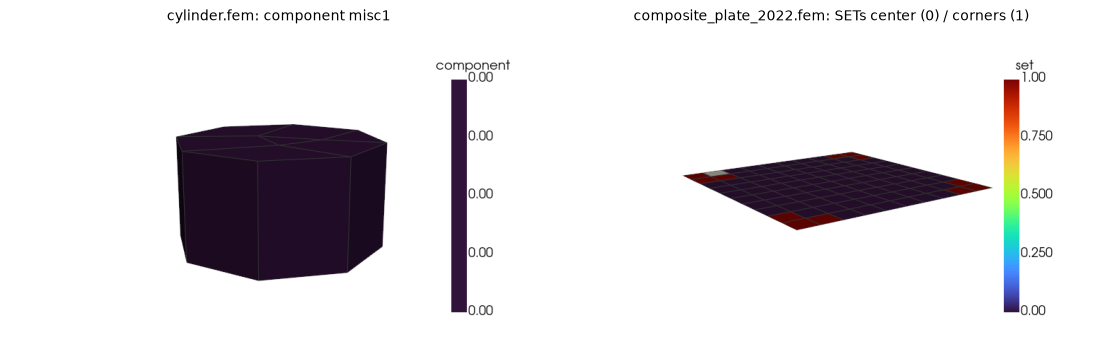

In [3]:
plate = mp.read(path('nastran', 'composite_plate_2022.fem'))
print(sorted((r.kind, r.name, len(r.entries)) for r in plate.regions))
gallery([
    (to_grid(cylinder, cell_data={'component': region_array(cylinder)}), 'component', 'cylinder.fem: component misc1', None),
    (to_grid(plate, cell_data={'set': region_array(plate, ['corners', 'center'])}), 'set', 'composite_plate_2022.fem: SETs center (0) / corners (1)', (0, 1)),
])

## Writing components back

Disjoint cell regions are written as HyperMesh components, as comments before `ENDDATA`, so a solver never sees them. A region's tag becomes the component id when every tag is usable. Here the cylinder is split into one component per element type and written by both engines. The comment blocks are byte-identical.

In [4]:
from meshioplusplus import _core
from meshioplusplus.nastran import _nastran as py_nastran

split = mp.Mesh(cylinder.points, cylinder.cells)
start = 0
regions = []
for k, c in enumerate(cylinder.cells):
    regions.append(mp.Region(c.type + 's', 'cell', np.arange(start, start + len(c.data)), -1, 10 * (k + 1)))
    start += len(c.data)
split.regions = regions
core_path, py_path = os.path.join(TMP, 'core.fem'), os.path.join(TMP, 'py.fem')
_core.nastran_write(core_path, split)
py_nastran.write(py_path, split)


def hm_block(p):
    lines = open(p).read().splitlines()
    return lines[lines.index('$'):]


print('identical comment blocks:', hm_block(core_path) == hm_block(py_path))
print('\n'.join(hm_block(core_path)[:9]))
back = mp.read(core_path)
print([(r.name, r.tag, len(r.entries)) for r in back.regions])

identical comment blocks: True
$
$HMMOVE       10
$              1THRU          17
$HMNAME COMP                  10"lines"
$
$HMMOVE       40
$             40THRU          57
$HMNAME COMP                  40"pyramids"
$
[('lines', 10, 17), ('pyramids', 40, 18), ('quads', 30, 18), ('tetras', 50, 63), ('triangles', 20, 4)]


## COMSOL: domains and Selections

`two_domains.mphtxt` holds a tetrahedron (domain 1) under a prism (domain 2), their boundary faces, edges and points, and three Selections. Each element's geometric entity index becomes `cell_data["mphtxt:geom"]`: domains count from 1, boundaries, edges and points from 0. A Selection becomes a cell region of its dimension. The labels show why strings are read by length rather than as words: one holds a blank, the other a `#`, which starts a comment anywhere else.

<meshio++ mesh object>
  Number of points: 7
  Number of cells:
    vertex: 2
    line: 2
    triangle: 3
    quad: 1
    tetra: 1
    wedge: 1
  Cell sets: Lower Part, Part #2, caps
  Cell data: mphtxt:geom
entity per block: [[0, 3], [0, 1], [0, 2, 1], [3], [1], [2]]
'Lower Part'   dim 3  cells [8]
'Part #2'      dim 3  cells [9]
'caps'         dim 2  cells [4, 6]


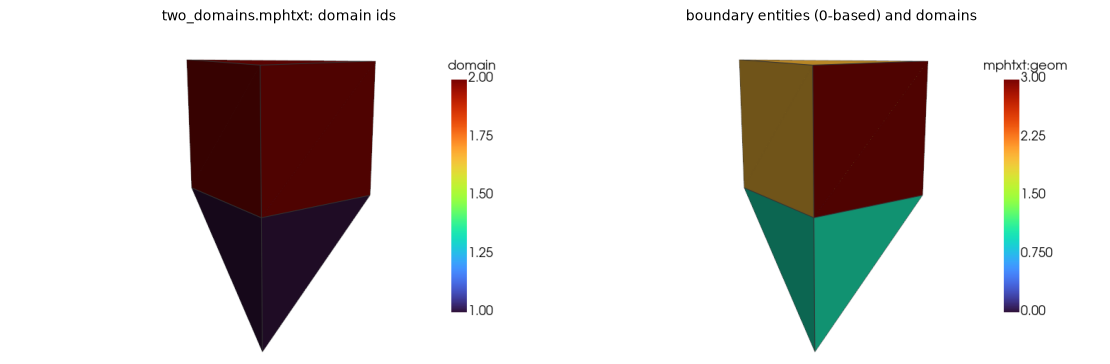

In [5]:
dom = mp.read(path('comsol', 'two_domains.mphtxt'))
print(dom)
print('entity per block:', [g.tolist() for g in dom.cell_data['mphtxt:geom']])
for r in dom.regions:
    print(f'{r.name!r:14s} dim {r.dim}  cells {r.entries.tolist()}')
solids = mp.Mesh(dom.points, dom.cells[4:])
gallery([
    (to_grid(solids, cell_data={'domain': [g.astype(float) for g in dom.cell_data['mphtxt:geom'][4:]]}), 'domain', 'two_domains.mphtxt: domain ids', (1, 2)),
    (to_grid(dom, cell_data={'mphtxt:geom': [g.astype(float) for g in dom.cell_data['mphtxt:geom']]}), 'mphtxt:geom', 'boundary entities (0-based) and domains', None),
])

## COMSOL's node order

COMSOL numbers an element's corners in tensor order (a quad is `0 1 3 2` as a ring), then every other node of its quadratic lattice lexicographically. For a `tri2` that is corners, then mid-edges 0–1, 0–2, 1–2; for a `hex2` the bottom-face centre comes ninth. meshio++ keeps these tables in its [node-ordering registry](../../doc/node_ordering.md). They agree with AWS Palace's COMSOL reader, and they put every mid-edge node of the published COMSOL files on its edge's midpoint. Before v16.1.0 meshio++ read quadratic COMSOL elements in the wrong order.

triangle6     file slot of each meshio++ node: [0, 1, 2, 3, 5, 4]
tetra10       file slot of each meshio++ node: [0, 1, 2, 3, 4, 6, 5, 7, 8, 9]
hexahedron27  file slot of each meshio++ node: [0, 1, 3, 2, 4, 5, 7, 6, 8, 11, 12, 9, 22, 25, 26, 23, 13, 15, 21, 19, 16, 18, 14, 20, 10, 24, 17]
['tetra10', 'pyramid14', 'wedge18', 'hexahedron27', 'triangle6', 'quad9', 'line3']
tetra10: largest mid-edge offset from its edge midpoint 0.0
hexahedron27: largest mid-edge offset from its edge midpoint 0.0


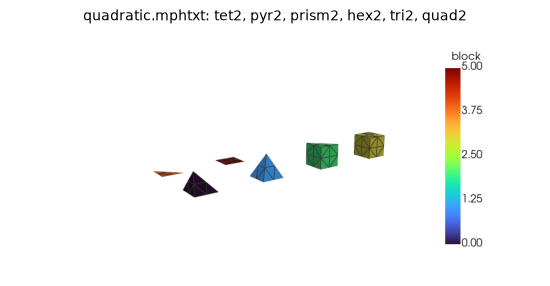

In [6]:
from meshioplusplus._node_order import node_order

for t in ('triangle6', 'tetra10', 'hexahedron27'):
    print(f'{t:13s} file slot of each meshio++ node:', list(node_order('mphtxt', t).to_meshio))

quad = mp.read(path('comsol', 'quadratic.mphtxt'))
print([c.type for c in quad.cells])
edges = {'tetra10': [(0, 1), (1, 2), (2, 0), (0, 3), (1, 3), (2, 3)],
         'hexahedron27': [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]}
for c in quad.cells:
    if c.type in edges:
        x = quad.points[c.data[0]]
        n = 4 if c.type == 'tetra10' else 8
        worst = max(np.abs(x[n + k] - (x[a] + x[b]) / 2).max() for k, (a, b) in enumerate(edges[c.type]))
        print(f'{c.type}: largest mid-edge offset from its edge midpoint {worst}')
# VTK has no 14-node pyramid: draw the pyr2 without its base centre.
drawn = mp.Mesh(quad.points, [('pyramid13', c.data[:, :13]) if c.type == 'pyramid14' else (c.type, c.data) for c in quad.cells])
gallery([(to_grid(drawn, cell_data={'block': [np.full(len(c.data), i, float) for i, c in enumerate(quad.cells)]}), 'block', 'quadratic.mphtxt: tet2, pyr2, prism2, hex2, tri2, quad2', None)], ncols=1, size=(900, 420))

## Text and binary

`.mphbin` holds the same values in binary: little-endian int32 and float64, one int32 per string character. Both engines write the same bytes in both forms, and a mesh survives the trip from one to the other.

In [7]:
from meshioplusplus.mphtxt import _mphtxt as py_mphtxt

binary = os.path.join(TMP, 'dom.mphbin')
mp.write(binary, dom)
again = mp.read(binary)
print('same selections:', [(r.name, r.entries.tolist()) for r in again.regions] == [(r.name, r.entries.tolist()) for r in dom.regions])
for ext, core_w, py_w in (('.mphtxt', _core.mphtxt_write, py_mphtxt.write), ('.mphbin', _core.mphbin_write, py_mphtxt.write_binary)):
    a, b = os.path.join(TMP, 'a' + ext), os.path.join(TMP, 'b' + ext)
    core_w(a, dom)
    py_w(b, dom)
    print(ext, 'engines write identical bytes:', open(a, 'rb').read() == open(b, 'rb').read(), f'({os.path.getsize(a)} bytes)')

same selections: True
.mphtxt engines write identical bytes: True (1963 bytes)
.mphbin engines write identical bytes: True (1168 bytes)


## From OptiStruct to COMSOL

COMSOL has no 20-node (serendipity) hexahedron, only the 27-node Lagrange one, so the deck is linearised first with `convert_cells`, which keeps its regions. Converting it to COMSOL then shows what the writer derives. The deck has no `mphtxt:geom`, so its disjoint cell regions number the entities: `solids` becomes domain 1, since domains are cells of the space dimension. The shells and the beam, which are lower-dimensional, become entities counted from 0. Every region that is a union of whole entities is written as a Selection. `set_2` mixes dimensions, and `base_nodes` is a point set, so the writer drops both with a warning.

In [8]:
fem_to_comsol = os.path.join(TMP, 'deck.mphtxt')
linear = mp.convert_cells(deck, 'linearize')
mp.write(fem_to_comsol, linear)
comsol = mp.read(fem_to_comsol)
print('entity per block:', [(c.type, g.tolist()) for c, g in zip(comsol.cells, comsol.cell_data['mphtxt:geom'])])
print('Selections:', [(r.name, r.dim, r.entries.tolist()) for r in comsol.regions])

entity per block: [('hexahedron', [1]), ('tetra', [1]), ('quad', [0]), ('triangle', [0]), ('line', [0])]
Selections: [('beams', 1, [4]), ('empty', 3, []), ('shells', 2, [2, 3]), ('solids', 3, [0, 1])]


## Onward

The same conversions from either CLI:

```sh
meshioplusplus convert model.fem model.vtu        # OptiStruct/Nastran deck, components as regions
meshioplusplus convert model.mphtxt model.med     # COMSOL domains and selections to Salome
meshioplusplus convert mesh.msh mesh.mphbin       # gmsh to COMSOL binary
```

What each reader accepts, what the writers derive and what they drop is on the [Nastran](../../doc/formats/nastran.md) and [COMSOL](../../doc/formats/mphtxt.md) format pages.